# Training the random forest model

Import dependencies

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

Load and prep dataset (issues with scaled data from previous folder)

In [2]:
df = pd.read_csv('/workspaces/2025SE_Gianfranco.M_CSAI/1. Data/csgo_round_snapshots.csv')

initialise encoder and scaler

In [3]:
label_encoder = LabelEncoder()
scaler = StandardScaler()

encode catergorial variables

In [ ]:
df['round_winner'] = label_encoder.fit_transform(df['round_winner'])
df['bomb_planted'] = label_encoder.fit_transform(df['bomb_planted'])
df['map'] = label_encoder.fit_transform(df['map'])

assign feature and target variables

In [5]:
X = df[['map','ct_money', 't_money', 'ct_players_alive', 't_players_alive', 'bomb_planted']]
y = df['round_winner']

### Split dataset

this function will split our dataset into a 20/80 split as defined with 'test_size=0.2'

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Initialisation of random forest model
we will now initialise the model, and train it on our X_train and y_train data.

In [8]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

now we will make predictions.

In [9]:
y_pred = rf_model.predict(X_test)

we can again evaluate the model's accuracy through a classification report

In [10]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.8182
              precision    recall  f1-score   support

           0       0.81      0.82      0.81     12004
           1       0.82      0.82      0.82     12478

    accuracy                           0.82     24482
   macro avg       0.82      0.82      0.82     24482
weighted avg       0.82      0.82      0.82     24482



and we can also plot a confusion matrix with our new split data

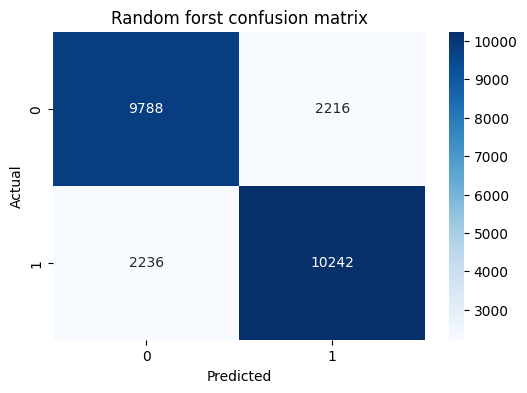

In [11]:
def plot_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Random forst confusion matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

plot_confusion_matrix(y_test, y_pred)

PICKLE the model, and other variables for later use.

In [13]:
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

with open('X_columns.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

with open('split_data.pkl', 'wb') as f:
    pickle.dump((X_train_scaled, X_test_scaled, y_train, y_test), f)